# Prep

In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("agileteam/bigdatacertificationkr")

print("Path to dataset files:", path)

ImportError: cannot import name 'get_web_endpoint' from 'kagglesdk.kaggle_env' (c:\Users\user\anaconda3\envs\ML\Lib\site-packages\kagglesdk\kaggle_env.py)

In [8]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("agileteam/bigdatacertificationkr")

print("Path to dataset files:", path)

ImportError: cannot import name 'get_web_endpoint' from 'kagglesdk.kaggle_env' (c:\Users\user\anaconda3\envs\ML\Lib\site-packages\kagglesdk\kaggle_env.py)

In [ ]:
import os
import pandas as pd 
import glob 

all_files = glob.glob(path+"/*")
file_names = [os.path.basename(f) for f in all_files]
for i in range(0,len(all_files),1):
    print(file_names[i])
#print("모든 파일 : ",all_files[-1])

employee_attrition.csv
diabetes_test.csv
cafe_sales.csv
sales_branch.csv
basic1.csv
overwork.csv
basic2.csv
daily_temperatures.csv
hamspam.csv
basic3.csv
t3_regression_data.csv
Insurance.csv
Customer_Data.csv
e-commerce.csv
diabetes_train.csv
christmas_decoration_sales.csv
Titanic.csv
payment.csv
gas_test.csv
high_blood_pressure.csv
gas_train.csv
ad_campaign.csv
subject_performance.csv
purchase.csv
heating.csv
t3_success.csv
basic1_json.json
website.csv
attrition.csv
basic1_xml.xml
sidedu.csv


In [ ]:
df = pd.read_csv(os.path.join(path,"Titanic.csv"))
display(df)

,PassengerId,Survived,Pclass,Name,Gender,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


# T1

## T1-1 이상치를 찾아라  
데이터에서 IQR 을 활용해 Fare 컬럼의 이상치를 찾고, 이상치 데이터의 여성수를 구하시오

In [ ]:
df = pd.read_csv(os.path.join(path,"Titanic.csv"))

In [ ]:
print(df.shape)
print(df.isnull().sum())
df.head()

(891, 12)
PassengerId      0
Survived         0
Pclass           0
Name             0
Gender           0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


,PassengerId,Survived,Pclass,Name,Gender,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [ ]:
import numpy as np 

Q1 = df['Fare'].quantile(0.25)
Q3 = df['Fare'].quantile(0.75)

IQR = Q3 - Q1
Q1 - 1.5*IQR, Q3+1.5*IQR

(-26.724, 65.6344)

In [ ]:
outdata1 = df[df['Fare']<(Q1-1.5*IQR)]
outdata2 = df[df['Fare']>(Q3+1.5*IQR)]
len(outdata1),len(outdata2)

display(outdata2.head())

,PassengerId,Survived,Pclass,Name,Gender,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
27,28,0,1,"Fortune, Mr. Charles Alexander",male,19.0,3,2,19950,263.0000,C23 C25 C27,S
31,32,1,1,"Spencer, Mrs. William Augustus (Marie Eugenie)",female,NaN,1,0,PC 17569,146.5208,B78,C
34,35,0,1,"Meyer, Mr. Edgar Joseph",male,28.0,1,0,PC 17604,82.1708,NaN,C
52,53,1,1,"Harper, Mrs. Henry Sleeper (Myna Haxtun)",female,49.0,1,0,PC 17572,76.7292,D33,C


In [ ]:
print(sum(outdata2['Gender']=='female'))

70


## T1-2 이상치를 찾아라 (소수점 나이) Expected Questions  
주어진 데이터에서 이상치(소수점 나이) 를 찾고 올림, 내림, 버림(절사) 했을 때 3가지 모두 이상치 'age' 평균을 구한 다음 모두 더하여 출력하시오

In [ ]:
df = pd.read_csv(os.path.join(path,'basic1.csv'))
print(df.isnull().sum())
print("0살 인 사람 합계 : ",(df['age']==0).sum())
df.head()

id       0
age      0
city     0
f1      31
f2       0
f3      95
f4       0
f5       0
dtype: int64
0살 인 사람 합계 :  1


,id,age,city,f1,f2,f3,f4,f5
0,id01,2.0,서울,NaN,0,NaN,ENFJ,91.297791
1,id02,9.0,서울,70.0,1,NaN,ENFJ,60.339826
2,id03,27.0,서울,61.0,1,NaN,ISTJ,17.252986
3,id04,75.0,서울,NaN,2,NaN,INFP,52.667078
4,id05,24.0,서울,85.0,2,NaN,ISFJ,29.269869


In [ ]:
import pandas as pd
import numpy as np 

# 소숫점 데이터 찾기
df = df[(df['age']-np.floor(df['age']))!=0]
df

,id,age,city,f1,f2,f3,f4,f5
6,id07,36.3,서울,60.0,1,NaN,ISFJ,9.796378
8,id09,3.3,서울,35.0,2,NaN,ESFJ,17.252986
21,id22,-6.3,부산,72.0,1,NaN,ENFP,52.667078
28,id29,-13.5,부산,47.0,2,NaN,ENTP,67.886373
46,id47,34.6,대구,75.0,1,NaN,ESTJ,90.496999
64,id65,26.5,경기,NaN,0,NaN,ISFP,91.297791
84,id85,83.6,경기,55.0,0,NaN,INFJ,80.138280
92,id93,21.8,경기,57.0,0,NaN,ISFP,73.586397


In [ ]:
# 올림
m_ceil = np.ceil(df['age']).mean()
# 내림
m_floor = np.floor(df['age']).mean()
# 버림
m_trunc = np.trunc(df['age']).mean()

print("올림 : {:.2f}".format(m_ceil))
print("내림 : {:.2f}".format(m_floor))
print("버림 : {:.2f}".format(m_trunc))

올림 : 23.75
내림 : 22.75
버림 : 23.00


In [ ]:
# 평균값 더한 다음 출력
print(m_ceil+m_floor+m_trunc)

69.5


## T1-3 결측치 처리
주어진 데이터에서 결측치가 80% 이상 되는 컬럼(변수) 삭제하고, 80% 미만인 결측치가 있는 컬럼은 'city' 별 중앙값으로 값을 대체하고 'f1' 컬럼의 평균값을 출력하세요

In [ ]:
df = pd.read_csv(os.path.join(path,"basic1.csv"))
df.head()

print(df.isnull().sum())

id       0
age      0
city     0
f1      31
f2       0
f3      95
f4       0
f5       0
dtype: int64


In [ ]:
df.shape

(100, 8)

In [ ]:
# 결츨 비율 확인
print(df.isnull().sum()/df.shape[0])
print(df.shape[0])

id      0.00
age     0.00
city    0.00
f1      0.31
f2      0.00
f3      0.95
f4      0.00
f5      0.00
dtype: float64
100


In [ ]:
df2 = df.drop(['f3'],axis=1)
display(df2.head())

,id,age,city,f1,f2,f4,f5
0,id01,2.0,서울,NaN,0,ENFJ,91.297791
1,id02,9.0,서울,70.0,1,ENFJ,60.339826
2,id03,27.0,서울,61.0,1,ISTJ,17.252986
3,id04,75.0,서울,NaN,2,INFP,52.667078
4,id05,24.0,서울,85.0,2,ISFJ,29.269869


In [ ]:
# 도시 확인
print(df['city'].unique())

# city 별 중앙값
df2[['f1']]=df2.groupby('city')[['f1']].transform(lambda x : x.fillna(x.median()))

['서울' '부산' '대구' '경기']


In [ ]:
display(df2)

,id,age,city,f1,f2,f4,f5
0,id01,2.0,서울,68.0,0,ENFJ,91.297791
1,id02,9.0,서울,70.0,1,ENFJ,60.339826
2,id03,27.0,서울,61.0,1,ISTJ,17.252986
3,id04,75.0,서울,68.0,2,INFP,52.667078
4,id05,24.0,서울,85.0,2,ISFJ,29.269869
...,...,...,...,...,...,...,...
95,id96,92.0,경기,53.0,1,ENTJ,52.667078
96,id97,100.0,경기,58.0,0,INFP,67.886373
97,id98,39.0,경기,58.0,2,INFP,98.429899
98,id99,1.0,경기,47.0,0,ESFJ,97.381034


In [ ]:
print(df2['f1'].mean())

65.52


## T1-4 왜도와 첨도 구하기 (로그 스케일)  
주어진 데이터 중 train.csv 에서 "SalePrice" 컬럼의 왜도와 첨도를 구한 값과, 'SalePrice' 컬럼을 스케일링(log1p) 로 변환한 이후 왜도와 첨도를 구해 모두 더한 다음 소수점 2째자리까지 출력하시오

In [ ]:
import kagglehub
import pandas as pd 
import os 
import numpy as np 

# 출력 최대 열의 개수 제한 해제
pd.set_option('display.max_columns',None)
df = pd.read_csv(r'/Users/isumi/Desktop/GitHub/BigData_Analysis_Exam/Data/train.csv')
df.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2003,2003,Gable,CompShg,VinylSd,VinylSd,BrkFace,196.0,Gd,TA,PConc,Gd,TA,No,GLQ,706,Unf,0,150,856,GasA,Ex,Y,SBrkr,856,854,0,1710,1,0,2,1,3,1,Gd,8,Typ,0,NaN,Attchd,2003.0,RFn,2,548,TA,TA,Y,0,61,0,0,0,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,Norm,1Fam,1Story,6,8,1976,1976,Gable,CompShg,MetalSd,MetalSd,NaN,0.0,TA,TA,CBlock,Gd,TA,Gd,ALQ,978,Unf,0,284,1262,GasA,Ex,Y,SBrkr,1262,0,0,1262,0,1,2,0,3,1,TA,6,Typ,1,TA,Attchd,1976.0,RFn,2,460,TA,TA,Y,298,0,0,0,0,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2001,2002,Gable,CompShg,VinylSd,VinylSd,BrkFace,162.0,Gd,TA,PConc,Gd,TA,Mn,GLQ,486,Unf,0,434,920,GasA,Ex,Y,SBrkr,920,866,0,1786,1,0,2,1,3,1,Gd,6,Typ,1,TA,Attchd,2001.0,RFn,2,608,TA,TA,Y,0,42,0,0,0,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,Norm,Norm,1Fam,2Story,7,5,1915,1970,Gable,CompShg,Wd Sdng,Wd Shng,NaN,0.0,TA,TA,BrkTil,TA,Gd,No,ALQ,216,Unf,0,540,756,GasA,Gd,Y,SBrkr,961,756,0,1717,1,0,1,0,3,1,Gd,7,Typ,1,Gd,Detchd,1998.0,Unf,3,642,TA,TA,Y,0,35,272,0,0,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,Norm,Norm,1Fam,2Story,8,5,2000,2000,Gable,CompShg,VinylSd,VinylSd,BrkFace,350.0,Gd,TA,PConc,Gd,TA,Av,GLQ,655,Unf,0,490,1145,GasA,Ex,Y,SBrkr,1145,1053,0,2198,1,0,2,1,4,1,Gd,9,Typ,1,TA,Attchd,2000.0,RFn,3,836,TA,TA,Y,192,84,0,0,0,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


'\n오른쪽으로 치우친 분포 (Right-skewed distrigion)\n양의 외도 분포 (Positively skewed distribution)\n    : 왜도를 계산하는 수식의 분자에 (평균-중앙값) 성분이 들어가는데 평균이 더 커서 양의 왜도\nmean=>median=>mode 순서ㄴ\n'

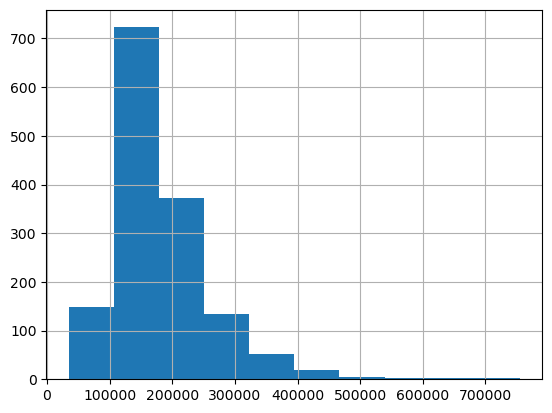

In [ ]:
df['SalePrice'].hist()
'''
오른쪽으로 치우친 분포 (Right-skewed distrigion)
양의 외도 분포 (Positively skewed distribution)
    : 왜도를 계산하는 수식의 분자에 (평균-중앙값) 성분이 들어가는데 평균이 더 커서 양의 왜도
mean=>median=>mode 순서ㄴ
'''

In [ ]:
# 왜도, 첨도 계산
s1 = df['SalePrice'].skew()
k1 = df['SalePrice'].kurt()
print("왜도 : ",s1)
print("첨도 : ",k1)

왜도 :  1.8828757597682129
첨도 :  6.536281860064529


In [ ]:
# 'SalePrice' 컬럼 로그 변환
df['SalePrice'] = np.log1p(df['SalePrice'])
''' 
np.log1p : 데이터 원본 변환
plt.loglog : 시각화 옵션
np.log : 자연 로그. np.log(0) 일 경우 무한대로 발산하여 ML Model 이 에러
np.log1p : ln(x+1). np.log(0) 방지하여 Boundary condition 만족
'''

' \nnp.log1p : 데이터 원본 변환\nplt.loglog : 시각화 옵션\nnp.log : 자연 로그. np.log(0) 일 경우 무한대로 발산하여 ML Model 이 에러\nnp.log1p : ln(x+1). np.log(0) 방지하여 Boundary condition 만족\n'

<Axes: >

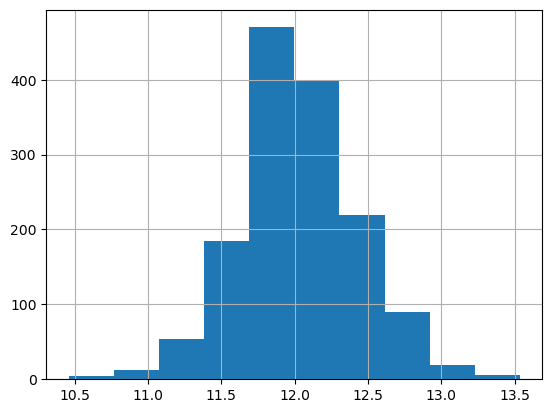

In [ ]:
# EDA
df['SalePrice'].hist()

In [ ]:
s2 = df['SalePrice'].skew()
k2 = df['SalePrice'].kurt()
print("왜도 : ",s2)
print("첨도 : ",k2)

왜도 :  0.12134661989685329
첨도 :  0.809519155707878


In [ ]:
print(round(s1+s2+k1+k2,2))

9.35


## T1-5 조건에 맞는 데이터 표준편차 구하기  
주어진 데이터 중 basic.csv 에서 'f4' 컬럼 값이 'ENFJ'와 'INFP' 인 'f1'의 표준편차 차이를 절대값으로 구하시오  

In [ ]:
import kagglehub
import os
import pandas as pd 
import glob 

path = kagglehub.dataset_download("agileteam/bigdatacertificationkr")

#all_files = glob.glob(path+"/*")
#file_names = [os.path.basename(f) for f in all_files]
#for i in range(0,len(all_files),1):
#    print(file_names[i])

df = pd.read_csv(os.path.join(path,"basic1.csv"))
display(df.head())

,id,age,city,f1,f2,f3,f4,f5
0,id01,2.0,서울,NaN,0,NaN,ENFJ,91.297791
1,id02,9.0,서울,70.0,1,NaN,ENFJ,60.339826
2,id03,27.0,서울,61.0,1,NaN,ISTJ,17.252986
3,id04,75.0,서울,NaN,2,NaN,INFP,52.667078
4,id05,24.0,서울,85.0,2,NaN,ISFJ,29.269869


In [ ]:
enfj = df.loc[df['f4']=='ENFJ','f1'].std()
infp = df.loc[df['f4']=='INFP','f1'].std()
print(abs(enfj-infp))

5.859621525876811


## T1-6 결측치 제거 및 그룹 합계
주어진 데이터 중 basic1.csv 에서 'f1'컬럼 결측 데이터를 제거하고, 'city' 와 'f2' 을 기준으로 묶어 합계를 구하고, 'city' 가 경기이면서 f2 가 0인 조건에서 만족하는 f1 값을 구하시오

In [ ]:
import kagglehub
import os
import pandas as pd 
import glob 

path = kagglehub.dataset_download("agileteam/bigdatacertificationkr")

df = pd.read_csv(os.path.join(path,"basic1.csv"))
display(df.head())

,id,age,city,f1,f2,f3,f4,f5
0,id01,2.0,서울,NaN,0,NaN,ENFJ,91.297791
1,id02,9.0,서울,70.0,1,NaN,ENFJ,60.339826
2,id03,27.0,서울,61.0,1,NaN,ISTJ,17.252986
3,id04,75.0,서울,NaN,2,NaN,INFP,52.667078
4,id05,24.0,서울,85.0,2,NaN,ISFJ,29.269869


In [ ]:
# f1 컬럼 결측치 제거
df = df.dropna(subset = ['f1'])

# 그룹 합계 계산
df2 = df.groupby(['city','f2']).sum()

# 조건에 맞는 값 출력
print(df.iloc[0]['f1'])


70.0


## T1-7 값 변경 및 2개 이상의 조건 
'f4' 컬럼의 값이 'ESFJ' 인 데이터를 'ISFJ" 로 대체하고, 'city' 가 '경기'이면서 'f4'가 'ISFJ' 인 데이터 중 'age' 컬럼의 최대값을 출력하시오


In [ ]:
import kagglehub
import os
import pandas as pd 
import glob 

path = kagglehub.dataset_download("agileteam/bigdatacertificationkr")

df = pd.read_csv(os.path.join(path,"basic1.csv"))
display(df.head())

,id,age,city,f1,f2,f3,f4,f5
0,id01,2.0,서울,NaN,0,NaN,ENFJ,91.297791
1,id02,9.0,서울,70.0,1,NaN,ENFJ,60.339826
2,id03,27.0,서울,61.0,1,NaN,ISTJ,17.252986
3,id04,75.0,서울,NaN,2,NaN,INFP,52.667078
4,id05,24.0,서울,85.0,2,NaN,ISFJ,29.269869


In [ ]:
df = pd.read_csv(os.path.join(path,"basic1.csv"))
df['f4'] = df['f4'].replace("ESFJ","ISFJ")
print(df[(df['f4']=="ISFJ")&(df['city']=="경기")]['age'].max())

90.0


## T1-8 누적합 그리고 보간 (결측치 처리)  
주어지 데이터 셋에서 'f2' 컬럼이 1인 조건에 해당하는 데이터의 'f1' 컬럼 누적합을 계산한다. 이때 발생하는 누적합 결측치는 바로 뒤의 값을 채우고, 누적합의 평균값을 출력한다. (단, 결측치 바로 뒤의 값이 없으면 다음에 나오는 값을 채워넣는다)


In [ ]:
import kagglehub
import os
import pandas as pd 
import glob 

path = kagglehub.dataset_download("agileteam/bigdatacertificationkr")

df = pd.read_csv(os.path.join(path,"basic1.csv"))
display(df.head())

f1_cumsum = list(df.loc[df['f2']==1]['f1'].cumsum())
print("'f2' 컬럼이 1 인 조건에 해당하는 데이터의 'f1' 컬럼 누적합 (결측 존재): ",f1_cumsum[-1])

# 결측치를 바로 뒤의 값으로 채웠을때

df['f1'] = df['f1'].fillna(method='bfill')
f1_cumsum2 = list(df.loc[df['f2']==1]['f1'].cumsum())
print("'f2' 컬럼이 1 인 조건에 해당하는 데이터의 'f1' 컬럼 누적합 (결측 제거): ",f1_cumsum2[-1])


df = pd.read_csv(os.path.join(path,"basic1.csv"))
df2 = df[df['f2']==1]['f1'].cumsum()
df2 = df2.fillna(method = 'bfill')
print(df2.mean())

,id,age,city,f1,f2,f3,f4,f5
0,id01,2.0,서울,NaN,0,NaN,ENFJ,91.297791
1,id02,9.0,서울,70.0,1,NaN,ENFJ,60.339826
2,id03,27.0,서울,61.0,1,NaN,ISTJ,17.252986
3,id04,75.0,서울,NaN,2,NaN,INFP,52.667078
4,id05,24.0,서울,85.0,2,NaN,ISFJ,29.269869


'f2' 컬럼이 1 인 조건에 해당하는 데이터의 'f1' 컬럼 누적합 (결측 존재):  1754.0
'f2' 컬럼이 1 인 조건에 해당하는 데이터의 'f1' 컬럼 누적합 (결측 제거):  2544.0
980.3783783783783


/var/folders/gw/jvr6w8xj12gc01xmg3zw29pw0000gn/T/ipykernel_33055/681411108.py:16: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df['f1'] = df['f1'].fillna(method='bfill')
/var/folders/gw/jvr6w8xj12gc01xmg3zw29pw0000gn/T/ipykernel_33055/681411108.py:23: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df2 = df2.fillna(method = 'bfill')


## T1-9 수치형 변수 표준화  
주어진 데이터에서 'f5' 컬럼을 표준화 (Standardization (Z-sore Normalization)) 하고 그 중앙값을 구하시오.  
$x' = \frac{x-\bar{x}}{\sigma}$

In [ ]:
import kagglehub
import os
import pandas as pd 
import glob 

path = kagglehub.dataset_download("agileteam/bigdatacertificationkr")

df = pd.read_csv(os.path.join(path,"basic1.csv"))
df.head(2)

,id,age,city,f1,f2,f3,f4,f5
0,id01,2.0,서울,NaN,0,NaN,ENFJ,91.297791
1,id02,9.0,서울,70.0,1,NaN,ENFJ,60.339826


In [ ]:
from sklearn.preprocessing import StandardScaler 

scaler = StandardScaler()
df['f5']=scaler.fit_transform(df[['f5']])
df.head()

,id,age,city,f1,f2,f3,f4,f5
0,id01,2.0,서울,NaN,0,NaN,ENFJ,1.220815
1,id02,9.0,서울,70.0,1,NaN,ENFJ,0.127343
2,id03,27.0,서울,61.0,1,NaN,ISTJ,-1.394535
3,id04,75.0,서울,NaN,2,NaN,INFP,-0.143667
4,id05,24.0,서울,85.0,2,NaN,ISFJ,-0.970085


In [ ]:
print(df['f5'].median())

0.260619629559015


## T1-10 Yeo-Johnson & Box-Cox  
여-존슨과 박스-칵스 변환  

주어진 데이터에서 20세 이상인 데이터를 추출하고 'f1' 컬럼을 결측치를 최빈값으로 채운 후, f1 컬럼의 여-존슨과 박스콕스 변환 값을 구하고, 두 값의 차이를 절댓값으로 구한다음 모두 더해 소숫점 둘째 자리까지 출력(반올림) 하시오  

Box-Cox  
$y_i^{(\lambda)}=\begin{cases} \frac{y_i^\lambda-1}{\lambda} & \text{if }\lambda\ne0,\\ \ln{y_i} & \text{if }\lambda=0\end{cases}$  
- 데이터에 매번 자연 로그나 제곱근을 일일이 취해보며 분포를 맞추는 대신, 변환 매개변수 람다를 데이터에 맞춰 최적화하는 방식 
- 오직 양수 데이터에만 적용할 수 있다. 데이터에 0이나 음수 값이 하나라도 섞여 있다면 수학적으로 연산이 불가능해져 에러를 발생시킨다.  
- 핵심 아이디어 : 데이터에 거듭제곱 $(x^\lambda)$ 을 적절히 먹여서 대칭 구조 (정규 분포) 로 만들자.
- 만약 데이터가 오른쪽으로 완만하게 기울어져있다면 제곱근을 취하고, 왜도가 아주 심하다면 더 강력하게 자연 로그를 취하는 방식 

Yeo-Johnson  
$y_i^((\lambda))=\begin{cases}
((y_i+1)^\lambda-1)/\lambda & \text{if }\lambda\ne0,y\ge0 \\
\log(y_i+1) & \text{if }\lambda=0, y\ge 0 \\
-((-y_i+1)^{(2-\lambda)}-1/(2-\lambda)) & \text{if } \lambda\ne2,y<0 \\
-\log(-y_i+1) & \text{if }\lambda=2, y<0
\end{cases}$
- 박스-칵스 변환이 가진 "음수나 0을 처리하지 못한다" 는 한계를 완벽히 극복하기 위해 2000년에 제안된 확장판 변환 기법 
- 데이터의 값이 양수냐 음수냐에 따라, 그리고 람다의 조건에 따라 수식이 4가지 분기점으로 세밀하게 작동 
- 자연 로그 기반이라 진수 조건때문에 $x\le 0$ 일때 정의가 안되지만, 여-존슨은 기본적으로 $x$ 대신 $(x+1)$ 을 사용하여 0부터 안전하게 시작.

In [ ]:
import kagglehub
import os
import pandas as pd 
import glob 

path = kagglehub.dataset_download("agileteam/bigdatacertificationkr")

df = pd.read_csv(os.path.join(path,"basic1.csv"))
df.head(2)

# 'f1' 결측치를 최빈값으로 채우기
print("조건 적용 전 : ",df.shape)
df = df[df['age']>=20] 
print("조건 적용 후 : ",df.shape)

조건 적용 전 :  (100, 8)
조건 적용 후 :  (83, 8)


In [ ]:
# 최빈값으로 'f1' 컬럼 결측치 대체
print("결측치 처리 전 : \n",df.isnull().sum())
print("최빈값 : ",df['f1'].mode()[0])
df['f1']=df['f1'].fillna(df['f1'].mode()[0])
print("결측치 처리 후 : \n",df.isnull().sum())

결측치 처리 전 : 
 id       0
age      0
city     0
f1      26
f2       0
f3      78
f4       0
f5       0
dtype: int64
최빈값 :  50.0
결측치 처리 후 : 
 id       0
age      0
city     0
f1       0
f2       0
f3      78
f4       0
f5       0
dtype: int64


In [ ]:
from sklearn.preprocessing import power_transform
# 여-존슨 값 구하기
df['y'] = power_transform(df[['f1']]) # method 디폴트 값은 여-존슨
print(df['y'].head())

# 

2    0.101083
3   -0.585402
4    1.463459
5   -0.143094
6    0.040578
Name: y, dtype: float64


In [ ]:
# 'f1' 데이터 박스-콕스 값 구하기 
display(df.head(2))
df['b'] = power_transform(df[['f1']],method='box-cox', standardize=False)
print(df['b'].head())
display(df.head(2))

,id,age,city,f1,f2,f3,f4,f5,y
2,id03,27.0,서울,61.0,1,NaN,ISTJ,17.252986,0.101083
3,id04,75.0,서울,50.0,2,NaN,INFP,52.667078,-0.585402


2    21.067089
3    18.305263
4    26.557679
5    20.084372
6    20.823544
Name: b, dtype: float64


,id,age,city,f1,f2,f3,f4,f5,y,b
2,id03,27.0,서울,61.0,1,NaN,ISTJ,17.252986,0.101083,21.067089
3,id04,75.0,서울,50.0,2,NaN,INFP,52.667078,-0.585402,18.305263


In [ ]:
## 박스콕스 방법2
from scipy import stats
x = stats.boxcox(df['f1'])
x

(array([21.06708862, 18.30526256, 26.55767894, 20.08437213, 20.82354418,
        29.92014364, 24.11822022, 22.7351046 , 18.30526256, 18.30526256,
        22.50056955, 26.55767894, 18.30526256, 26.98922181, 18.30526256,
        18.30526256, 24.34492159, 16.71079081, 18.30526256, 20.08437213,
        20.82354418, 13.87430298, 24.79522775, 21.78961488, 28.47348779,
        18.30526256, 18.30526256, 24.79522775, 18.30526256, 18.30526256,
        18.30526256, 24.34492159, 19.58413814, 17.78149093, 20.82354418,
        18.30526256, 27.20371085, 18.30526256, 24.34492159, 27.20371085,
        25.01886862, 18.30526256, 25.90374721, 18.30526256, 18.30526256,
        21.55009488, 18.30526256, 18.30526256, 18.30526256, 21.3092623 ,
        18.30526256, 26.77388228, 21.3092623 , 18.30526256, 18.30526256,
        18.82186843, 16.98150163, 26.55767894, 26.34059809, 18.30526256,
        29.3045178 , 17.5167931 ,  6.25392507, 12.96923681, 28.89049306,
        18.30526256, 20.82354418, 18.30526256, 18.3

In [ ]:
#(반올림)
round(sum(np.abs(df['y'] - df['b'])),2)

1715.05

## T1-11 min-max 기준 상하위 5% 값 
min-max 스케일링 기준 상하위 5% 구하기  
주어진 데이터에서 'f5' 컬럼을 min-max 스케일 변환한 후, 상위 5%와 하위 5% 값의 합을 구하시오  

In [ ]:
import kagglehub
import os
import pandas as pd 
import glob 

path = kagglehub.dataset_download("agileteam/bigdatacertificationkr")

df = pd.read_csv(os.path.join(path,"basic1.csv"))
df.head(2)

# EDA 
print(df.isnull().sum())

# min-max scale 방법1
from sklearn.preprocessing import MinMaxScaler 
scaler = MinMaxScaler()
df['f5_1'] = scaler.fit_transform(df[['f5']])

# min-max scaler 방법2 
df['f5_2'] = df['f5'].transform(lambda x : ((x-x.min())/(x.max()-x.min())))

# 방법1과 2비교 
print(df.head())

id       0
age      0
city     0
f1      31
f2       0
f3      95
f4       0
f5       0
dtype: int64
     id   age city    f1  f2   f3    f4         f5      f5_1      f5_2
0  id01   2.0   서울   NaN   0  NaN  ENFJ  91.297791  0.919533  0.919533
1  id02   9.0   서울  70.0   1  NaN  ENFJ  60.339826  0.570252  0.570252
2  id03  27.0   서울  61.0   1  NaN  ISTJ  17.252986  0.084129  0.084129
3  id04  75.0   서울   NaN   2  NaN  INFP  52.667078  0.483685  0.483685
4  id05  24.0   서울  85.0   2  NaN  ISFJ  29.269869  0.219708  0.219708


In [ ]:
# 하위 5%, 상위 5% 값 구하기 
lower = df['f5_1'].quantile(0.05)
print(lower)

upper = df['f5_1'].quantile(0.95)
print(upper)

print(lower+upper)

0.03670782406038746
0.9881662742993513
1.0248740983597389


## T1-12 상위10개, 하위10개 차이  
주어지 데이터에서 상위 10개 국가의 접종률 평균과 하위 10개 국가의 접종률 평균을 구하고, 그 차이를 구하고, 그 차이를 구해보세요.  
(단, 100% 넘는 접종률 제거, 소수 첫째자리까지 출력)  


In [ ]:
import kagglehub
import os
import pandas as pd 
import glob 

df = pd.read_csv(r"/Users/isumi/Desktop/GitHub/BigData_Analysis_Exam/Data/covid-vaccination-vs-death_ratio.csv")
df.head(2)

,Unnamed: 0,country,iso_code,date,total_vaccinations,people_vaccinated,people_fully_vaccinated,New_deaths,population,ratio
0,0,Afghanistan,AFG,2021-05-11,504502.0,448878.0,55624.0,12,40374668.0,1.111781
1,1,Afghanistan,AFG,2021-05-20,547901.0,470341.0,77560.0,10,40374668.0,1.164941


In [ ]:
df2 = df.groupby('country').max()
df2 = df2.sort_values(by='ratio',ascending=False).reset_index()
cond = df2['ratio']<= 100
df2 = df2[cond]

top10 = df2[0:10]
low10 = df2[-11:-1]

top10_vaccine_mean = top10['ratio'].mean()
low10_vaccine_mean = low10['ratio'].mean()
print(round(top10_vaccine_mean-low10_vaccine_mean,1))

87.6


## T1-13 상관관게 구하기  
주어진 데이터에서 상관관계를 구하고, quality 와의 상관관계가 가장 큰 값과, 가장 작은 값을 구한 다음 더하시오.   
단, quality 와 quality 상관관계 제외, 소숫점 둘째 자리까지 반올림하여 계산  



In [ ]:
import numpy as np 
import pandas as pd 
import os 

df = pd.read_csv(r"/Users/isumi/Desktop/GitHub/BigData_Analysis_Exam/Data/winequality-red.csv")
display(df.head(2))

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.0,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.0,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5


In [ ]:
# 상관관계 구하기 
df_corr = df.corr()
display(df_corr)

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
fixed acidity,1.000000,-0.256131,0.671703,0.114777,0.093705,-0.153794,-0.113181,0.668047,-0.682978,0.183006,-0.061668,0.124052
volatile acidity,-0.256131,1.000000,-0.552496,0.001918,0.061298,-0.010504,0.076470,0.022026,0.234937,-0.260987,-0.202288,-0.390558
citric acid,0.671703,-0.552496,1.000000,0.143577,0.203823,-0.060978,0.035533,0.364947,-0.541904,0.312770,0.109903,0.226373
residual sugar,0.114777,0.001918,0.143577,1.000000,0.055610,0.187049,0.203028,0.355283,-0.085652,0.005527,0.042075,0.013732
chlorides,0.093705,0.061298,0.203823,0.055610,1.000000,0.005562,0.047400,0.200632,-0.265026,0.371260,-0.221141,-0.128907
free sulfur dioxide,-0.153794,-0.010504,-0.060978,0.187049,0.005562,1.000000,0.667666,-0.021946,0.070377,0.051658,-0.069408,-0.050656
total sulfur dioxide,-0.113181,0.076470,0.035533,0.203028,0.047400,0.667666,1.000000,0.071269,-0.066495,0.042947,-0.205654,-0.185100
density,0.668047,0.022026,0.364947,0.355283,0.200632,-0.021946,0.071269,1.000000,-0.341699,0.148506,-0.496180,-0.174919
pH,-0.682978,0.234937,-0.541904,-0.085652,-0.265026,0.070377,-0.066495,-0.341699,1.000000,-0.196648,0.205633,-0.057731
sulphates,0.183006,-0.260987,0.312770,0.005527,0.371260,0.051658,0.042947,0.148506,-0.196648,1.000000,0.093595,0.251397


In [ ]:
df_corr = df_corr[:-1] # quality-quality 상관관계 제거
display(df_corr)

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
fixed acidity,1.000000,-0.256131,0.671703,0.114777,0.093705,-0.153794,-0.113181,0.668047,-0.682978,0.183006,-0.061668,0.124052
volatile acidity,-0.256131,1.000000,-0.552496,0.001918,0.061298,-0.010504,0.076470,0.022026,0.234937,-0.260987,-0.202288,-0.390558
citric acid,0.671703,-0.552496,1.000000,0.143577,0.203823,-0.060978,0.035533,0.364947,-0.541904,0.312770,0.109903,0.226373
residual sugar,0.114777,0.001918,0.143577,1.000000,0.055610,0.187049,0.203028,0.355283,-0.085652,0.005527,0.042075,0.013732
chlorides,0.093705,0.061298,0.203823,0.055610,1.000000,0.005562,0.047400,0.200632,-0.265026,0.371260,-0.221141,-0.128907
free sulfur dioxide,-0.153794,-0.010504,-0.060978,0.187049,0.005562,1.000000,0.667666,-0.021946,0.070377,0.051658,-0.069408,-0.050656
total sulfur dioxide,-0.113181,0.076470,0.035533,0.203028,0.047400,0.667666,1.000000,0.071269,-0.066495,0.042947,-0.205654,-0.185100
density,0.668047,0.022026,0.364947,0.355283,0.200632,-0.021946,0.071269,1.000000,-0.341699,0.148506,-0.496180,-0.174919
pH,-0.682978,0.234937,-0.541904,-0.085652,-0.265026,0.070377,-0.066495,-0.341699,1.000000,-0.196648,0.205633,-0.057731
sulphates,0.183006,-0.260987,0.312770,0.005527,0.371260,0.051658,0.042947,0.148506,-0.196648,1.000000,0.093595,0.251397


In [ ]:
# 상관관계가 가장 큰 값과 가장 작은 값 
max_corr = abs(df.corr()['quality'][:-1]).max()
min_corr = abs(df.corr()['quality'][:-1]).min()

print(max_corr)
print(min_corr)
#if max_corr not in df.corr()[['quality']][:-1].values:
#    max_corr=-max_corr

print(round(max_corr+min_corr,2))

0.47616632400113656
0.013731637340065814
0.49


## T1-14 MultiIndex + Groupby  
city 와 f4 를 기준으로 f5의 평균값을 구한 다음, f5를 기준으로 상위 7개 값을 모두 더해 출력하시오 (소숫점 둘째자리까지 출력)

In [ ]:
import kagglehub
import os 
import numpy as np 
import pandas as pd 

# Download latest version
path = kagglehub.dataset_download("agileteam/bigdatacertificationkr")
df = pd.read_csv(os.path.join(path,"basic1.csv"))
display(df.head(2))

/Users/isumi/anaconda3/envs/ML/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


,id,age,city,f1,f2,f3,f4,f5
0,id01,2.0,서울,NaN,0,NaN,ENFJ,91.297791
1,id02,9.0,서울,70.0,1,NaN,ENFJ,60.339826


In [ ]:
df2 = df.groupby(['city','f4'])[['f5']].mean().reset_index()
df2.sort_values('f5',ascending=False,inplace=True)
#display(df2)

f5s = df2[0:6]
display(f5s)
print(round(f5s['f5'].sum(),2))

,city,f4,f5
36,서울,ENFP,98.429899
2,경기,ESFJ,97.381034
44,서울,INTJ,91.297791
41,서울,ESTP,91.297791
47,서울,ISFP,91.057640
7,경기,INFP,90.531801


560.0


## T1-15 슬라이싱 & 조건 
주어진 데이터 셋에서 age 컬럼 상위 20개의 데이터를 구한 다음 f1의 결측치를 중앙값으로 채운다.
그리고 f4가 ISFJ 와 f5가 20 이상인 f1의 평균값을 출력하시오

In [ ]:
import kagglehub
import os 
import numpy as np 
import pandas as pd 

# Download latest version
path = kagglehub.dataset_download("agileteam/bigdatacertificationkr")
df = pd.read_csv(os.path.join(path,"basic1.csv"))
display(df.head(2))

,id,age,city,f1,f2,f3,f4,f5
0,id01,2.0,서울,NaN,0,NaN,ENFJ,91.297791
1,id02,9.0,서울,70.0,1,NaN,ENFJ,60.339826


In [ ]:
# age 컬럼 상위 20개의 데이터 
df2 = df.sort_values('age',ascending=False)
df3 = df2[0:20]
#print(df3)


#display(df3.head(3))
# f1 결측치 중앙값으로 채우기
df3['f1'] = df3['f1'].fillna(df['f1'].median())

# f4 가 ISFJ 와 f5가 20 이사인 f1의 평균값 구하기
df4 = df3[(df3['f4']=='ISFJ') & (df3['f5']>=20)]
display(df4)

print(df4['f1'].mean())

,id,age,city,f1,f2,f3,f4,f5
3,id52,97.0,대구,82.0,1,NaN,ISFJ,90.496999
9,id73,90.0,경기,77.5,1,NaN,ISFJ,73.586397
12,id63,88.0,경기,86.0,1,NaN,ISFJ,73.586397
17,id81,86.0,경기,50.0,1,NaN,ISFJ,37.113739


73.875


## T1-16 분산 
주어진 데이터 셋에서 f2가 0값인 데이터를 age 기준으로 오름차순 정렬하고 앞에서부터 20개의 데이터를 추출한 후 f1 결측치(최소값)을 채우기 전과 후의 분산 차이를 계산하시오 (소숫점 둘째 자리까지)

In [ ]:
import kagglehub
import os 
import numpy as np 
import pandas as pd 

# Download latest version
path = kagglehub.dataset_download("agileteam/bigdatacertificationkr")
df = pd.read_csv(os.path.join(path,"basic1.csv"))
display(df.head(2))

df1 = df[df['f2']==0].sort_values('age',ascending=True).reset_index()
display(df1.head(2))

df2 = df1[:20]

# 결측치 채우기 전
bf_f1 = round(df2['f1'].var(),2)
print("f1 결측치 채우기 전 : ",round(df2['f1'].var(),2))

# 결측치 채운 후 
df2['f1'] = df2['f1'].fillna(df2['f1'].min()) 
af_f1 = round(df2['f1'].var(),2)
print("f1 결측치 채운 후 : ",round(df2['f1'].var(),2))

print("두 결측치 분산 차이 : ",af_f1-bf_f1)

,id,age,city,f1,f2,f3,f4,f5
0,id01,2.0,서울,NaN,0,NaN,ENFJ,91.297791
1,id02,9.0,서울,70.0,1,NaN,ENFJ,60.339826


,index,id,age,city,f1,f2,f3,f4,f5
0,98,id99,1.0,경기,47.0,0,NaN,ESFJ,97.381034
1,0,id01,2.0,서울,NaN,0,NaN,ENFJ,91.297791


f1 결측치 채우기 전 :  351.76
f1 결측치 채운 후 :  313.33
두 결측치 분산 차이 :  -38.43000000000001


/var/folders/gw/jvr6w8xj12gc01xmg3zw29pw0000gn/T/ipykernel_1490/562518555.py:21: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df2['f1'] = df2['f1'].fillna(df2['f1'].min())


## T1-17 시계열 데이터1 
2022년 5월 sales의 중앙값을 구하시오

In [ ]:
import kagglehub
import os 
import numpy as np 
import pandas as pd 
import datetime

# Download latest version
path = kagglehub.dataset_download("agileteam/bigdatacertificationkr")
df = pd.read_csv(os.path.join(path,"basic2.csv"))
display(df.head(2))

,Date,Sales,PV,UV,Events
0,2022-01-01,22711525,397349,4421.0,1
1,2022-01-02,36779,3969,2289.0,0


In [ ]:
print(df.info())
print(df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 730 entries, 0 to 729
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Date    730 non-null    object 
 1   Sales   730 non-null    int64  
 2   PV      730 non-null    int64  
 3   UV      684 non-null    float64
 4   Events  730 non-null    int64  
dtypes: float64(1), int64(3), object(1)
memory usage: 28.6+ KB
None
Date       0
Sales      0
PV         0
UV        46
Events     0
dtype: int64


In [ ]:
# Datetime 으로 type 변경
df['Date'] = pd.to_datetime(df['Date'])
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 730 entries, 0 to 729
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   Date    730 non-null    datetime64[ns]
 1   Sales   730 non-null    int64         
 2   PV      730 non-null    int64         
 3   UV      684 non-null    float64       
 4   Events  730 non-null    int64         
dtypes: datetime64[ns](1), float64(1), int64(3)
memory usage: 28.6 KB


In [ ]:
# 새로운 컬럼 추가
df['year'] = df['Date'].dt.year
df['month'] = df['Date'].dt.month 
df['day'] = df['Date'].dt.day

df.head(2)

,Date,Sales,PV,UV,Events,year,month,day
0,2022-01-01,22711525,397349,4421.0,1,2022,1,1
1,2022-01-02,36779,3969,2289.0,0,2022,1,2


In [ ]:
df2 = df[(df['year']==2022)&(df['month']==5)]
display(df2.head(2))

,Date,Sales,PV,UV,Events,year,month,day
120,2022-05-01,976303,45225,1142.0,0,2022,5,1
121,2022-05-02,7394853,262116,2959.0,1,2022,5,2


In [ ]:
print(df2['Sales'].median())

1477685.0


## T1-18 시계열 데이터2 
주어진 데이터에서 2022년 5월 주말과 평일의 sales컬럼 평균값 차이를 절댓값으로 구하시오 (소숫점 둘째자리까지 출력, 반올림)

In [ ]:
import kagglehub
import os 
import numpy as np 
import pandas as pd 
import datetime

# Download latest version
path = kagglehub.dataset_download("agileteam/bigdatacertificationkr")
df = pd.read_csv(os.path.join(path,"basic2.csv"))
display(df.head(2))

df['Date'] = pd.to_datetime(df['Date'])
df['year'] = df['Date'].dt.year
df['month'] = df['Date'].dt.month 
df['day'] = df['Date'].dt.day  
df['dayofweek'] = df['Date'].dt.dayofweek

display(df.head(2))


,Date,Sales,PV,UV,Events
0,2022-01-01,22711525,397349,4421.0,1
1,2022-01-02,36779,3969,2289.0,0


,Date,Sales,PV,UV,Events,year,month,day,dayofweek
0,2022-01-01,22711525,397349,4421.0,1,2022,1,1,5
1,2022-01-02,36779,3969,2289.0,0,2022,1,2,6


In [ ]:
week = df[(df['year']==2022)&(df['month']==5)&(df['dayofweek']>=5)]
weekend = df[(df['year']==2022)&(df['month']==5)&(df['dayofweek']<5)]

week_sales = week['Sales'].mean()
weekend_sales = weekend['Sales'].mean()

print(abs(week_sales-weekend_sales))

3010339.1010101014


## T1-19 시계열 데이터3 
주어지 데이터에서 2022년 월별 Sales 합계 중 가장 큰 금액과 2023년 월별 Sales 합계 중 가장 큰 금액의 차이를 절대값으로 구하시오  
단 Events 컬럼이 1 인 경우 80%의 Sales 값만 반영함  
(최종값은 소숫점 반올림 후 정수 출력)

In [ ]:
import kagglehub
import os 
import numpy as np 
import pandas as pd 
import datetime

# Download latest version
path = kagglehub.dataset_download("agileteam/bigdatacertificationkr")
df = pd.read_csv(os.path.join(path,"basic2.csv"))
display(df.head(2))

df['Date'] = pd.to_datetime(df['Date'])
df['year'] = df['Date'].dt.year 
df['month'] = df['Date'].dt.month 

#df2 = df.groupby(['year','month'])['Sales'].sum().reset_index()
#display(df2.head(2))
# 이벤트가 1일때 Sales 값은 80% 만 반영
def event_sales(x) :
    if x['Events'] == 1 :
        x['Sales2'] = x['Sales']*0.8
    else : 
        x['Sales2'] = x['Sales']
    return x 

df = df.apply(lambda x : event_sales(x),axis=1)
df.head(2)

df2 = df.groupby(['year','month'])['Sales2'].sum().reset_index()
max_2022 = df2[df2['year']==2022]['Sales2'].max()
max_2023 = df2[df2['year']==2023]['Sales2'].max()

print(round(abs(max_2022-max_2023),2))

,Date,Sales,PV,UV,Events
0,2022-01-01,22711525,397349,4421.0,1
1,2022-01-02,36779,3969,2289.0,0


42473435.8


## T1-20 데이터 병합 
basic1 데이터와 basic3 데이터를 basic1의 'f4' 값을 기준으로 병합하고, 병합한 데이터에서 r2 결측치를 제거한 다음, 앞에서부터 20개 데이터를 선택하고 'f2' 컬럼 합을 구하시오 

In [ ]:
import kagglehub
import os 
import numpy as np 
import pandas as pd 
import datetime

# Download latest version
path = kagglehub.dataset_download("agileteam/bigdatacertificationkr")
b1 = pd.read_csv(os.path.join(path,"basic1.csv"))
b3 = pd.read_csv(os.path.join(path,"basic3.csv"))

display(b1.head(2))
display(b3.head(2))

,id,age,city,f1,f2,f3,f4,f5
0,id01,2.0,서울,NaN,0,NaN,ENFJ,91.297791
1,id02,9.0,서울,70.0,1,NaN,ENFJ,60.339826


,f4,r1,r2
0,INFP,ENFJ,ENTJ
1,ENFP,INFJ,NaN


In [ ]:
# 데이터 결합
df = pd.merge(left=b1,right=b3,how='left',on='f4')
df.head(2)
print(len(df))

100


In [ ]:
# r2 결측치 제거
df.dropna(subset=['r2'],inplace=True)
display(df.head(2))
# 앞에서부터 20개 데이터를 선택하여 'f2' 컬럼 합 구하기 
print(df.iloc[:20]['f2'].sum())

,id,age,city,f1,f2,f3,f4,f5,r1,r2
0,id01,2.0,서울,NaN,0,NaN,ENFJ,91.297791,INFP,ISFP
1,id02,9.0,서울,70.0,1,NaN,ENFJ,60.339826,INFP,ISFP


15


## T1-21 Binning Data
나이 구간 나누기  
basic1 데이터 중 'age' 컬럼 이상치를 제거하고, 동일한 개수로 나이 순으로 3 그룹으로 나눈 뒤 각 그룹의 중앙값을 더하시오    
(이상치는 음수 (0포함), 소숫점 값)

In [ ]:
import kagglehub
import os 
import numpy as np 
import pandas as pd 
import datetime

# Download latest version
path = kagglehub.dataset_download("agileteam/bigdatacertificationkr")
df = pd.read_csv(os.path.join(path,"basic1.csv"))

print("전체 데이터 : ",df.shape)
df = df[~(df['age']<=0)]
print("음수 (0포함) 값 제거 후 데이터 크기 : ",df.shape)

df = df[(df['age']==round(df['age'],0))]
print("소수점 제거 후 데이터 크기 : ",df.shape)

display(df.head(2))

전체 데이터 :  (100, 8)
음수 (0포함) 값 제거 후 데이터 크기 :  (96, 8)
소수점 제거 후 데이터 크기 :  (90, 8)


,id,age,city,f1,f2,f3,f4,f5
0,id01,2.0,서울,NaN,0,NaN,ENFJ,91.297791
1,id02,9.0,서울,70.0,1,NaN,ENFJ,60.339826


In [ ]:
# 기준 확인
pd.qcut(df['age'],q=3)
# pd.qcut() : 데이터 프레임 특정열을 데이터 개수가 똑같아지도록 등간격 (분위수 기준) 으로 쪼갬 
# 데이터셋의 나이 (age) 를 일렬로 쭉 세운 뒤, 전체 샘플 개수를 정확히 3등분 한다. 
# 그럼 데이터 원래 행 위치에 맞춰 구간값이 적힌 라벨을 알려준다. 

# pd.cut() 을 절대적인 값 기준으로 자른다. 

# ( 소괄호 : 초과 (포함하지 않음)
# ] 대괄호 : 이하 (포함함)
# (0.999, 38.667] : 나이가 0.999 세 초과이고 38.667 세 이하인 데이터들이 이 그룹에 속한다.

0      (0.999, 38.667]
1      (0.999, 38.667]
2      (0.999, 38.667]
3      (73.333, 100.0]
4      (0.999, 38.667]
            ...       
95     (73.333, 100.0]
96     (73.333, 100.0]
97    (38.667, 73.333]
98     (0.999, 38.667]
99    (38.667, 73.333]
Name: age, Length: 90, dtype: category
Categories (3, interval[float64, right]): [(0.999, 38.667] < (38.667, 73.333] < (73.333, 100.0]]

In [ ]:
# 구간 분할
df['range'] = pd.qcut(df['age'], q=3, labels=['group1','group2','group3'])
df['range'].value_counts()
display(df.head())

,id,age,city,f1,f2,f3,f4,f5,range
0,id01,2.0,서울,NaN,0,NaN,ENFJ,91.297791,group1
1,id02,9.0,서울,70.0,1,NaN,ENFJ,60.339826,group1
2,id03,27.0,서울,61.0,1,NaN,ISTJ,17.252986,group1
3,id04,75.0,서울,NaN,2,NaN,INFP,52.667078,group3
4,id05,24.0,서울,85.0,2,NaN,ISFJ,29.269869,group1


In [ ]:
# 중간 이상 - 중간 이하
g1_med = df[df['range']=='group1']['age'].median()
g2_med = df[df['range']=='group2']['age'].median()
g3_med = df[df['range']=='group3']['age'].median()

print(g1_med+g2_med+g3_med)

165.0


## T1-22 Time-Series4
주어진 데이터(basic2.csv)에서 주 단위 Sales의 합계를 구하고, 가장 큰 값을 가진 주와 작은 값을 가진 주의 차이를 구하시오 (절댓값)

In [ ]:
import kagglehub
import os 
import numpy as np 
import pandas as pd 
import datetime

# Download latest version
path = kagglehub.dataset_download("agileteam/bigdatacertificationkr")
df = pd.read_csv(os.path.join(path,"basic2.csv"))
df['Date'] = pd.to_datetime(df['Date'])
df = df.set_index('Date')

display(df.head(2))

,Sales,PV,UV,Events
Date,,,,
2022-01-01,22711525,397349,4421.0,1
2022-01-02,36779,3969,2289.0,0


In [ ]:
print(df.shape)

(730, 4)


In [ ]:
df_w = df.resample('W').sum().reset_index()
df_w.head()
# resample : 시계열 데이터에서 원하는 시간 간격으로 데이터를 다시 묶어서 집계하는 메서드
# D (Day), W (Week), M (Month, 월말기준), MS (Month Start, 월초기준)
# Q (Quarter), Y (Year) 가 있다.

,Date,Sales,PV,UV,Events
0,2022-01-02,22748304,401318,6710.0,1
1,2022-01-09,33373822,1148464,15189.0,2
2,2022-01-16,20754519,283773,9344.0,0
3,2022-01-23,21880751,538633,9841.0,1
4,2022-01-30,28878452,560814,7808.0,1


In [ ]:
print(max(df_w['Sales'])-min(df_w['Sales']))

91639050


## T1-23 중복 데이터 제거 
- f1의 결측치를 채운 후 age 컬럼의 중복 제거 전과 후의 'f1' 중앙값 차이를 구하시오
    - 결측치는 'f1' 데이터에서 큰 값 순으로 정렬했을 때 10번째에 위치한 값으로 채운다. 
    - 중복 데이터 발생 시 뒤에 나오는 데이터를 삭제함 
    - 최종 결과값은 절대값으로 출력 

중복 제거 기준 : 제공된 데이터 순서대로 중복 데이터 발생시 뒤에 나오는 데이터를 삭제함

In [ ]:
import kagglehub
import os 
import numpy as np 
import pandas as pd 
import datetime

# Download latest version
path = kagglehub.dataset_download("agileteam/bigdatacertificationkr")
df = pd.read_csv(os.path.join(path,"basic1.csv"))
display(df.head(2))

,id,age,city,f1,f2,f3,f4,f5
0,id01,2.0,서울,NaN,0,NaN,ENFJ,91.297791
1,id02,9.0,서울,70.0,1,NaN,ENFJ,60.339826


In [ ]:
# f1 데이터에서 10번째로 큰 값으로 결측치를 채움
top10 = df['f1'].sort_values(ascending=False).iloc[9]
df['f1']=df['f1'].fillna(top10)

# 중복 제거 전의 중앙값
result1 = df['f1'].median()
print(result1)

# 중복 제거 후의 중앙값
df = df.drop_duplicates(subset=['age'])
result2 = df['f1'].median()
print(result2)

print("중앙값 차이 : ",abs(result1-result2))

77.5
77.0
중앙값 차이 :  0.5


## T1-24 Lagged Feature  시차 데이터 생성 
주어진 데이터 (basic2.csv) 에서 'pv' 컬럼으로 1일 시차(lag)가 있는 새로운 컬럼을 만들고 (예: 1월 2일에는 1월 1일 pv 데이터를 넣고, 1월 3일에는 1월 2일 pv 데이터를 넣음), 새로운 컬럼의 1월 1일은 다음날 (1월 2일)데이터로 결측치를 채운 다음, Events가 1이면서 Sales가 1000000 이하인 조건에 맞는 새로운 컬럼 합을 구하시오


In [ ]:
import kagglehub
import os 
import numpy as np 
import pandas as pd 
import datetime

# Download latest version
path = kagglehub.dataset_download("agileteam/bigdatacertificationkr")
df = pd.read_csv(os.path.join(path,"basic2.csv"))
display(df.head(2))

,Date,Sales,PV,UV,Events
0,2022-01-01,22711525,397349,4421.0,1
1,2022-01-02,36779,3969,2289.0,0


In [ ]:
# 결측치 확인 
df.isnull().sum()

Date       0
Sales      0
PV         0
UV        46
Events     0
dtype: int64

In [ ]:
# 1일 차이가 나는 시차 특성 만들기
df['previous_PV'] = df['PV'].shift(1)
df.head()

,Date,Sales,PV,UV,Events,previous_PV
0,2022-01-01,22711525,397349,4421.0,1,NaN
1,2022-01-02,36779,3969,2289.0,0,397349.0
2,2022-01-03,13943875,373890,NaN,1,3969.0
3,2022-01-04,8088593,142054,2157.0,0,373890.0
4,2022-01-05,2395374,190684,NaN,0,142054.0


In [ ]:
# 1일씩 미뤘음으로 가장 앞이 결측값이 됨
df['previous_PV'] = df['previous_PV'].fillna(method='bfill')
df.head()

/var/folders/gw/jvr6w8xj12gc01xmg3zw29pw0000gn/T/ipykernel_1490/3002016326.py:2: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df['previous_PV'] = df['previous_PV'].fillna(method='bfill')


,Date,Sales,PV,UV,Events,previous_PV
0,2022-01-01,22711525,397349,4421.0,1,397349.0
1,2022-01-02,36779,3969,2289.0,0,397349.0
2,2022-01-03,13943875,373890,NaN,1,3969.0
3,2022-01-04,8088593,142054,2157.0,0,373890.0
4,2022-01-05,2395374,190684,NaN,0,142054.0


In [ ]:
# 조건에 맞는 1일 이전 PV 의 합
cond = (df['Events']==1)&(df['Sales']<=1000000)
print(df[cond]['previous_PV'].sum())

1894876.0


## T1-25 str_slicing 
basic1 데이터에서 f4가 E로 시작하면서 부산에 살고 20대인 사람은 몇 명일까요?